In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "studentportuguese"
namex = "Portuguese"

d = 30

###knn
graphsx = np.load("../graphs/"+name+"_knn_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/studentportuguese_knn_graphsummary.npy")
randomgraphsinfo


,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Student-portguese (30),1,224,46,20,26,1.0,0.486607,0.513393,4.869565,0.033352,0.017417,0.015935,109,115,0,0,0
1,Student-portguese (30),2,224,48,20,28,2.0,0.982143,1.017857,9.333333,0.140415,0.078075,0.062340,70,74,0,0,1
2,Student-portguese (30),3,224,48,20,28,3.0,1.540179,1.459821,14.000000,0.301650,0.179012,0.122638,38,36,0,0,2
3,Student-portguese (30),4,224,49,21,28,4.0,2.120536,1.879464,18.285714,0.528828,0.324952,0.203876,26,22,0,0,3
4,Student-portguese (30),5,224,50,22,28,5.0,2.656250,2.343750,22.400000,0.819827,0.505445,0.314382,17,13,0,0,4
5,Student-portguese (30),6,224,50,22,28,6.0,3.245536,2.754464,26.880000,1.146621,0.726297,0.420324,12,8,0,0,5
6,Student-portguese (30),7,224,50,22,28,7.0,3.781250,3.218750,31.360000,1.535714,0.975336,0.560378,3,6,0,0,6
7,Student-portguese (30),8,224,50,22,28,8.0,4.348214,3.651786,35.840000,1.973374,1.259009,0.714366,3,2,0,0,7
8,Student-portguese (30),9,224,50,22,28,9.0,4.955357,4.044643,40.320000,2.506246,1.621076,0.885170,1,1,0,0,8
9,Student-portguese (30),10,224,50,22,28,10.0,5.571429,4.428571,44.800000,3.055133,1.991832,1.063301,1,0,0,0,9


## Compute and evaluate results for the targeted intervention model

In [4]:
summary_dfx = scripts.analytics.compute_itm_results(datasgraphs = graphsx,
                                                      thresh=False,
                                                      dsetname = name,
                                                      dsetdim = d)

summary_dfx.to_csv("./im_results/"+name+"_boost_results_knn.csv", index=False)
summary_dfx.head(10)

,K,B,Sg,Sg_lbls,F(Sg),Sgb,Sgb_lbls,F(Sgb)b4B,F(Sgb),Boostedgb,...,Boostedbg,usedBbudgetbg,kmax,n,m,greedyTime,greedyBoostTime,boostGreedyTime,dataset,graphid
0,1,4,{},{},109.0,{},{},109.0,113.0,"[1, 3, 4, 6]",...,"[1, 3, 4, 6]",4,1,224,46,0.037020,0.038112,0.035357,studentportuguese (30),0
1,1,3,{},{},109.0,{},{},109.0,112.0,"[1, 3, 4]",...,"[1, 3, 4]",3,1,224,46,0.038668,0.042216,0.040977,studentportuguese (30),0
2,1,2,{},{},109.0,{},{},109.0,111.0,"[1, 3]",...,"[1, 3]",2,1,224,46,0.037254,0.036080,0.035020,studentportuguese (30),0
3,1,1,{},{},109.0,{},{},109.0,110.0,[1],...,[1],1,1,224,46,0.035345,0.036924,0.042407,studentportuguese (30),0
4,1,0,{},{},109.0,{},{},109.0,109.0,[],...,[],0,1,224,46,0.035256,0.038070,0.038257,studentportuguese (30),0
5,2,4,{},{},109.0,{},{},109.0,113.0,"[1, 3, 4, 6]",...,"[1, 3, 4, 6]",4,1,224,46,0.034341,0.033677,0.032966,studentportuguese (30),0
6,2,3,{},{},109.0,{},{},109.0,112.0,"[1, 3, 4]",...,"[1, 3, 4]",3,1,224,46,0.032578,0.033869,0.035638,studentportuguese (30),0
7,2,2,{},{},109.0,{},{},109.0,111.0,"[1, 3]",...,"[1, 3]",2,1,224,46,0.033662,0.032278,0.032777,studentportuguese (30),0
8,2,1,{},{},109.0,{},{},109.0,110.0,[1],...,[1],1,1,224,46,0.034308,0.034453,0.033465,studentportuguese (30),0
9,2,0,{},{},109.0,{},{},109.0,109.0,[],...,[],0,1,224,46,0.033223,0.033915,0.033269,studentportuguese (30),0


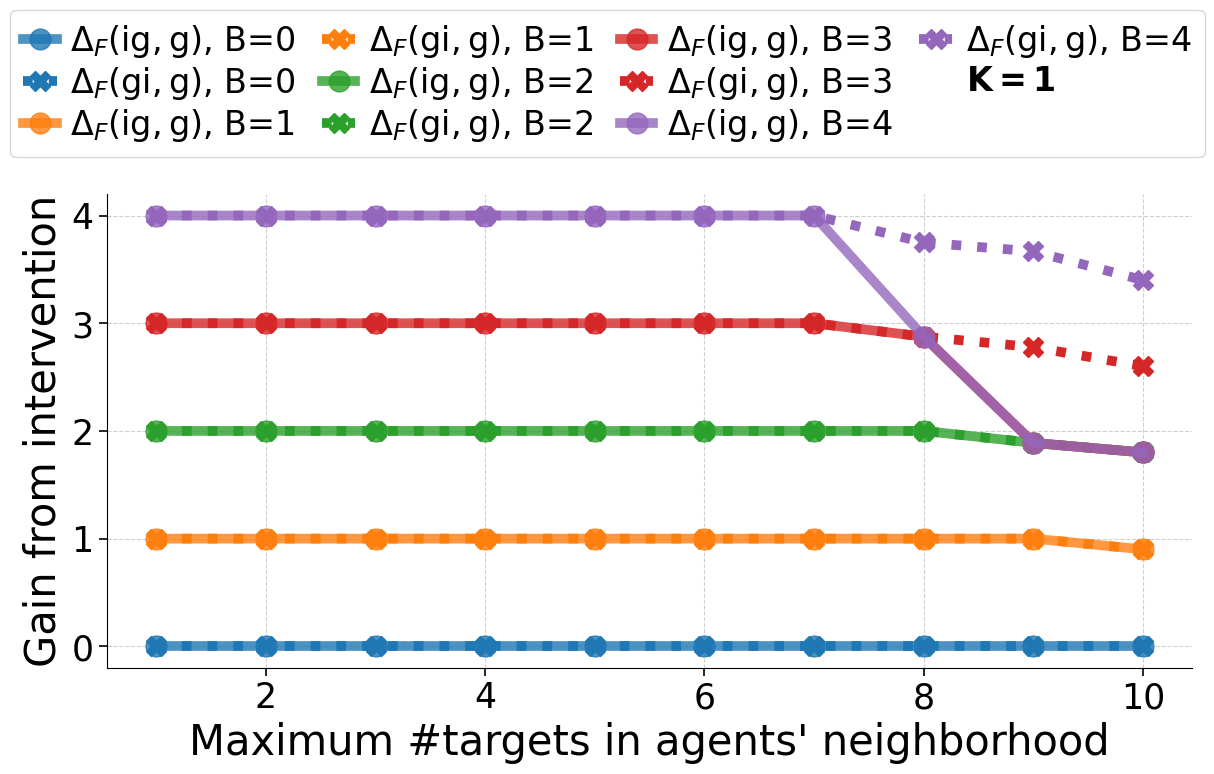

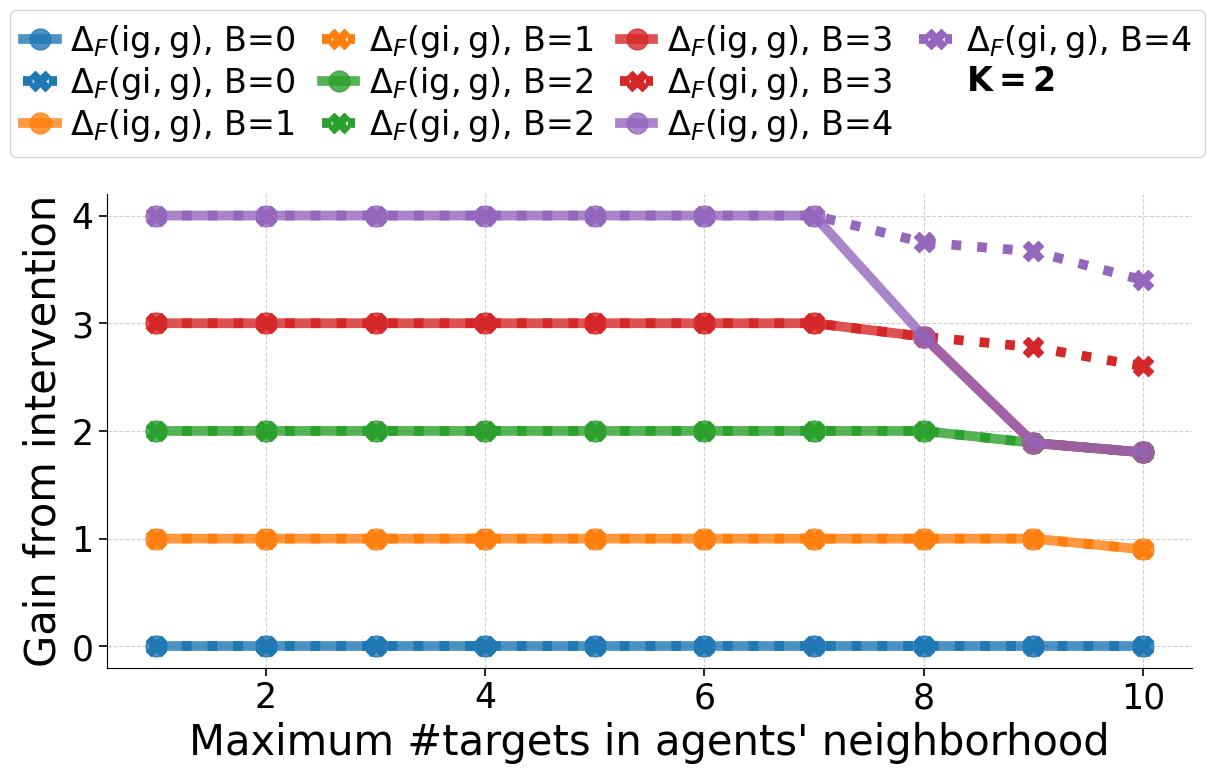

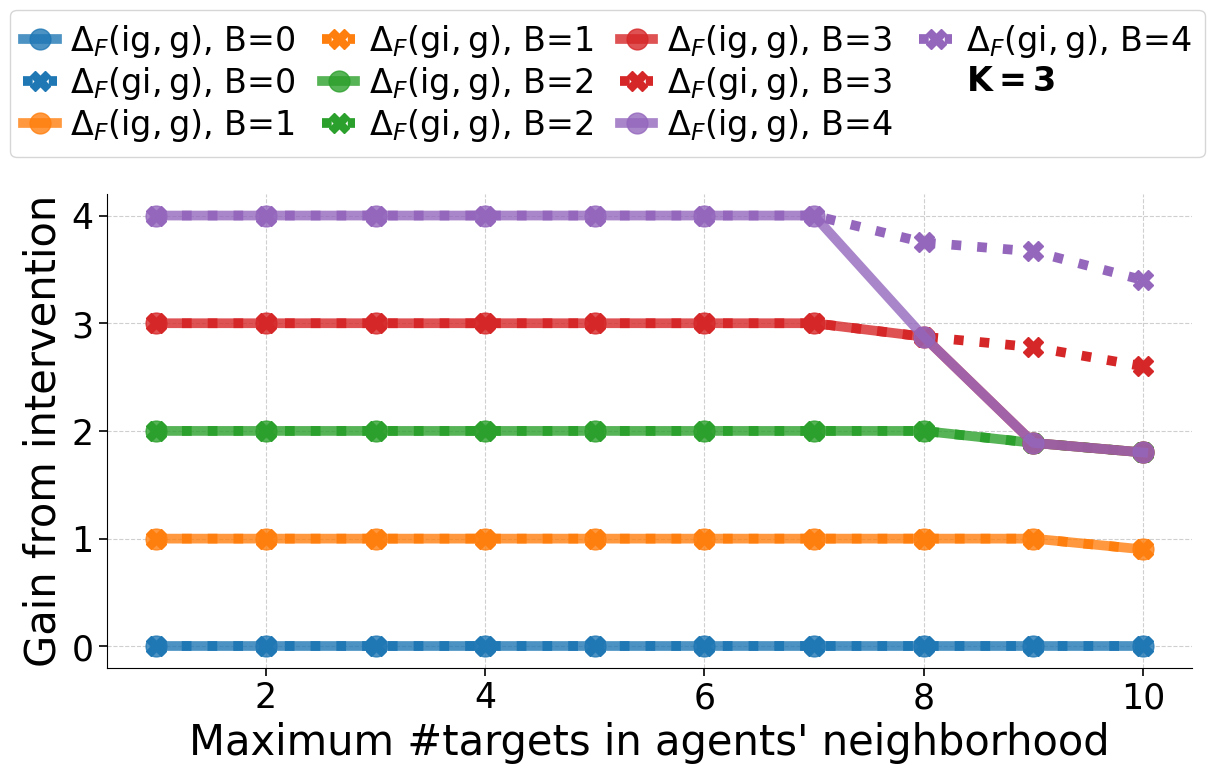

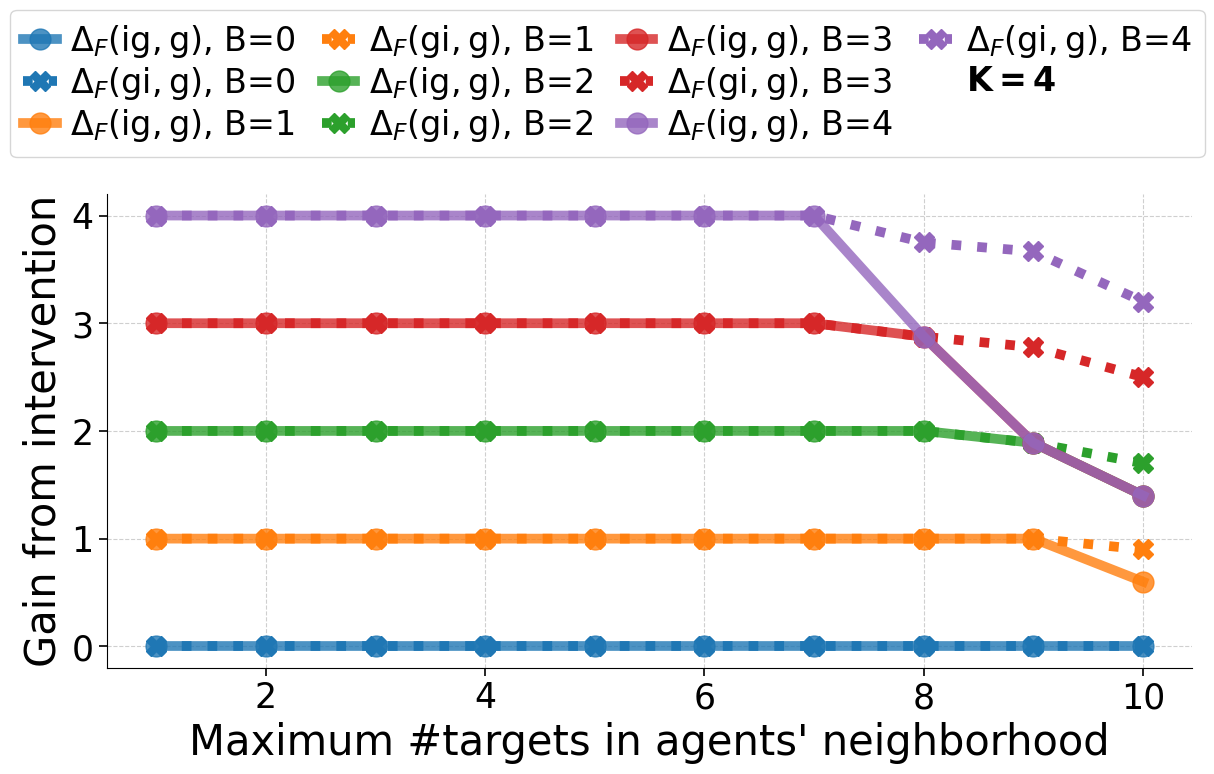

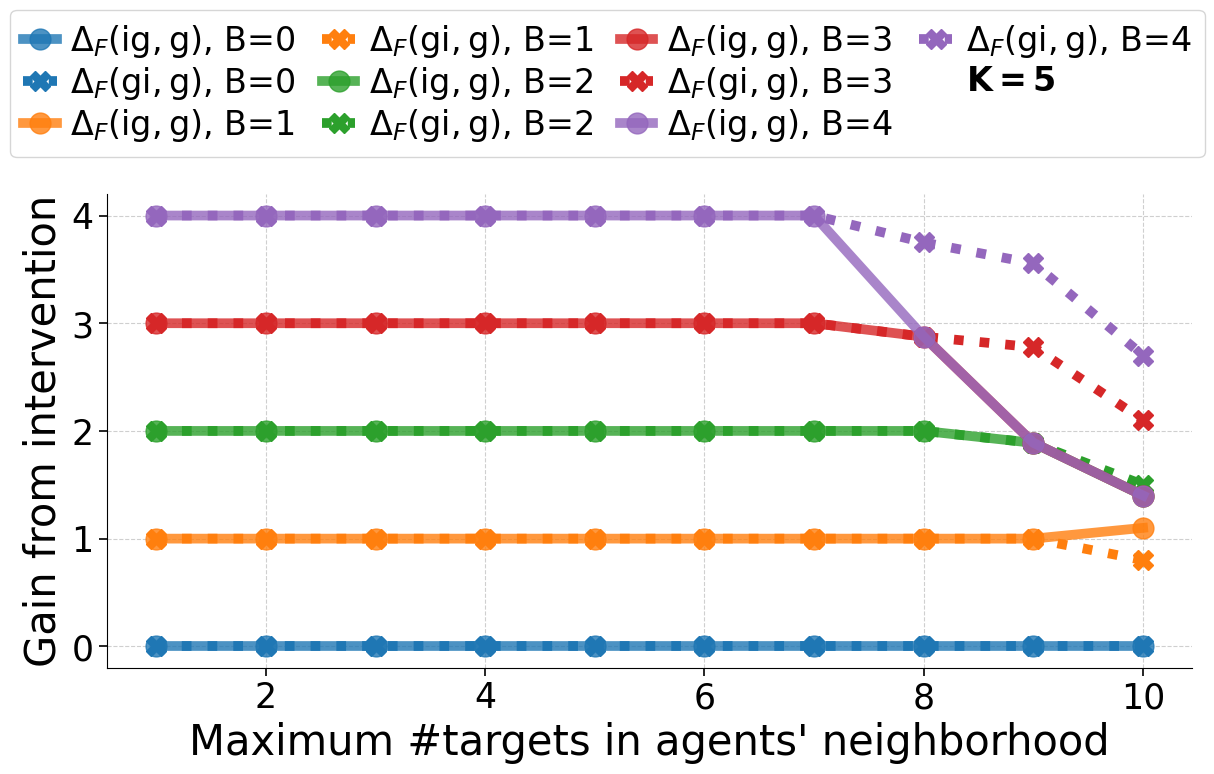

In [5]:
scripts.analytics.plot_intm_results(resdf = summary_dfx,
                                      thresh=False,
                                      save_as = "./im_results/figures/"+name+"_imb4aftersm_results_knn")